In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# ── Load dataset on Google Colab ──────────────────────────────────────────────
from google.colab import files
print("Please upload your mtsamples.csv file...")
uploaded = files.upload()  # A file picker will pop up — select mtsamples.csv

df = pd.read_csv('mtsamples.csv')

print(f'Dataset shape: {df.shape}')
print(f'Column list: {df.columns.tolist()}')

df['transcription'] = df['transcription'].fillna('')

specialities = df['medical_specialty'].value_counts()
print(f'\nSpecialities:\n{specialities}')

plt.figure(figsize=(12, 6))
specialities.plot(kind='bar', color='steelblue')
plt.title("All medical specialities in the dataset")
plt.ylabel("Number of Transcripts")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from wordcloud import WordCloud

# ── Read dataset on Kaggle ──────────────────────────────────────────────
# Check the exact folder name created in your right sidebar under 'Input'
# It usually matches your dataset's name (e.g., 'mtsamples')
file_path = '/kaggle/input/datasets/sohambose2oo3/my-medical-data/mtsamples.csv'
# Replace 'my-medical-data' with the exact title you typed when uploading


if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully!")
else:
    # If the path isn't exactly right, this prints out everything in the directory to help you find it
    print("File not found at default path. Checking directory structure...")
    for dirname, _, filenames in os.walk('/kaggle/input'):
        for filename in filenames:
            print(os.path.join(dirname, filename))

Dataset loaded successfully!


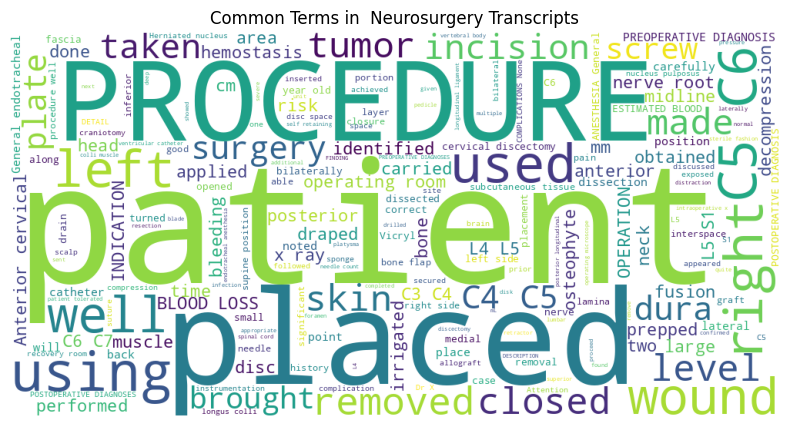

In [2]:
try:
    speciality = ' Neurosurgery'
    if speciality in df['medical_specialty'].values:
        texts = df[df['medical_specialty']==speciality]['transcription']
        if not texts.empty:
            text = ' '.join(texts.astype(str))
            if len(text.strip()) > 0:
                wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(text)
                plt.figure(figsize=(10,5))
                plt.imshow(wordcloud)
                plt.axis("off")
                plt.title(f"Common Terms in {speciality} Transcripts")
                plt.show()

            else:
                print(f"No valid text found for {speciality}")
        else:
            print(f"No transcriptions available for {speciality}")
    else:
        print("Speciality not found in dataset")

except Exception as e:
    print("Error:", str(e))

In [3]:
import re
import nltk
from tqdm import tqdm
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# ── Fix 1: Download punkt_tab (required in newer NLTK versions) ───────────────
nltk.download(['stopwords', 'punkt', 'punkt_tab'], quiet=True)

def clean_text(text):
    if not isinstance(text, str):
        return ""                        # Fix 2: always return a string

    medical_terms = {
        'dr', 'pt', 'mr', 'mri', 'ct', 'hr', 'bp', 'rr', 'spo2',
        'ekg', 'cbc', 'er', 'or', 'ed', 'icu', 'lab'
    }
    try:
        text = text.lower()
        text = re.sub(r'\[.*?\]', '', text)
        text = re.sub(r'\b\d+[\.\d]*\b', '', text)
        text = re.sub(r'[^\w\s]', ' ', text)

        words = word_tokenize(text)
        stop_words = set(stopwords.words('english')) - medical_terms
        filtered_words = [w for w in words if w not in stop_words and len(w) > 1]

        return ' '.join(filtered_words)

    except Exception as e:
        print(f'Error while processing text: {e}')
        return ""                        # Fix 3: return "" instead of None on error

tqdm.pandas(desc="Cleaning Text")
df['clean_text'] = df['transcription'].progress_apply(clean_text)

empty_text = df['clean_text'].str.strip().eq('').sum()

print(f"\nDiagnostics:")
print(f" Original samples : {len(df)}")
print(f" Empty results    : {empty_text} ({empty_text/len(df):.1%})")
print("\nSample Before:\n", df['transcription'].iloc[0][:200])
print("\nSample After:\n",  df['clean_text'].iloc[0][:200])

Cleaning Text: 100%|██████████| 4999/4999 [00:08<00:00, 598.90it/s]


Diagnostics:
 Original samples : 4999
 Empty results    : 33 (0.7%)

Sample Before:
 SUBJECTIVE:,  This 23-year-old white female presents with complaint of allergies.  She used to have allergies when she lived in Seattle but she thinks they are worse here.  In the past, she has tried 

Sample After:
 subjective year old white female presents complaint allergies used allergies lived seattle thinks worse past tried claritin zyrtec worked short time seemed lose effectiveness used allegra also used la


In [4]:
# IMPORTS & LIFECYCLE INITIALIZATION ────────────────────────────────
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import classification_report, accuracy_score

from imblearn.over_sampling import SMOTE
from transformers import DistilBertTokenizer, DistilBertModel

# Verify if GPU acceleration is available for DistilBERT
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [6]:
# TARGET & FEATURE PREPARATION ──────────────────────────────────────
# Filter out missing targets if any
df = df.dropna(subset=['medical_specialty'])

X = df[['keywords', 'transcription', 'description']].copy()
y = df['medical_specialty']

# Handle missing strings to avoid downstream vectorizer failures
X['keywords'] = X['keywords'].fillna('')
X['description'] = X['description'].fillna('')
X['transcription'] = X['transcription'].fillna('')

# Combine columns specifically for DistilBERT processing
X['bert_text'] = X['description'] + " " + X['transcription']

print(f"Feature set dimensions: {X.shape}")
print(f"Target series dimensions: {y.shape}")


Feature set dimensions: (4999, 4)
Target series dimensions: (4999,)


In [7]:
# FILTER TOP 5 CLASSES ONLY ──────────────────────────────────────
print("Original class count:", df['medical_specialty'].nunique())

# 1. Identify the top 5 medical specialties by volume
top_5_specialties = df['medical_specialty'].value_counts().nlargest(5).index.tolist()

# 2. Filter the dataframe to keep only these top 5 classes
df_filtered = df[df['medical_specialty'].isin(top_5_specialties)].copy()

# 3. Re-assign features and targets using the filtered dataset
X = df_filtered[['keywords', 'transcription', 'description']].copy()
y = df_filtered['medical_specialty']

# 4. Re-handle missing strings and combine columns for DistilBERT
X['keywords'] = X['keywords'].fillna('')
X['description'] = X['description'].fillna('')
X['transcription'] = X['transcription'].fillna('')
X['bert_text'] = X['description'] + " " + X['transcription']

print("\nFiltered to Top 5 Classes:")
for idx, (specialty, count) in enumerate(y.value_counts().items(), 1):
    print(f"  {idx}. {specialty.strip()}: {count} samples")

print(f"\nNew Feature set dimensions: {X.shape}")
print(f"New Target series dimensions: {y.shape}")

Original class count: 40

Filtered to Top 5 Classes:
  1. Surgery: 1103 samples
  2. Consult - History and Phy.: 516 samples
  3. Cardiovascular / Pulmonary: 372 samples
  4. Orthopedic: 355 samples
  5. Radiology: 273 samples

New Feature set dimensions: (2619, 4)
New Target series dimensions: (2619,)


In [8]:
# STRATIFIED TRAIN-TEST SPLIT ───────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training subset samples: {len(X_train)}")
print(f"Testing subset samples: {len(X_test)}")

Training subset samples: 2095
Testing subset samples: 524


In [9]:
# TF-IDF ON KEYWORDS ────────────────────────────────────────────────
print("Extracting TF-IDF features from 'keywords'...")
tfidf = TfidfVectorizer(max_features=1000)

X_train_tfidf = tfidf.fit_transform(X_train['keywords'])
X_test_tfidf = tfidf.transform(X_test['keywords'])

print(f"Train TF-IDF shape: {X_train_tfidf.shape}")
print(f"Test TF-IDF shape: {X_test_tfidf.shape}")

Extracting TF-IDF features from 'keywords'...
Train TF-IDF shape: (2095, 1000)
Test TF-IDF shape: (524, 1000)


In [10]:
# DISTILBERT EMBEDDINGS EXTRACTION ──────────────────────────────────
print("Loading pre-trained DistilBERT configuration...")
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model = DistilBertModel.from_pretrained('distilbert-base-uncased').to(device)
model.eval()

def get_bert_embeddings(text_series, batch_size=32):
    embeddings = []
    texts = text_series.tolist()

    for i in tqdm(range(0, len(texts), batch_size), desc="Extracting"):
        batch_texts = texts[i:i+batch_size]
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=256,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            # Pull out [CLS] token (index 0) representational vectors
            cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(cls_embeddings)

    return np.vstack(embeddings)

print("\nGenerating Train Embeddings:")
X_train_bert = get_bert_embeddings(X_train['bert_text'])

print("\nGenerating Test Embeddings:")
X_test_bert = get_bert_embeddings(X_test['bert_text'])

Loading pre-trained DistilBERT configuration...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Generating Train Embeddings:


Extracting: 100%|██████████| 66/66 [00:15<00:00,  4.29it/s]



Generating Test Embeddings:


Extracting: 100%|██████████| 17/17 [00:03<00:00,  4.47it/s]


In [11]:
# FEATURE FUSION & DENSE SCALING ────────────────────────────────────
print("Fusing TF-IDF and BERT matrices...")
X_train_combined = hstack([X_train_tfidf, csr_matrix(X_train_bert)]).toarray()
X_test_combined = hstack([X_test_tfidf, csr_matrix(X_test_bert)]).toarray()

print("Applying Standard Scaling to the concatenated matrix...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_combined)
X_test_scaled = scaler.transform(X_test_combined)

print(f"Final Scaled Train matrix: {X_train_scaled.shape}")
print(f"Final Scaled Test matrix: {X_test_scaled.shape}")

Fusing TF-IDF and BERT matrices...
Applying Standard Scaling to the concatenated matrix...
Final Scaled Train matrix: (2095, 1768)
Final Scaled Test matrix: (524, 1768)


In [12]:
# SMOTE IMBALANCE RESAMPLING ────────────────────────────────────────
print("Calculating minimum class representation...")
min_samples = y_train.value_counts().min()
k_neighbors = min(5, max(1, min_samples - 1))

print(f"Applying SMOTE (k_neighbors adaptive setting: {k_neighbors})...")
smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Balanced Train Feature matrix shape: {X_train_resampled.shape}")
print(f"Balanced Train Target distribution: \n{y_train_resampled.value_counts()}")

Calculating minimum class representation...
Applying SMOTE (k_neighbors adaptive setting: 5)...
Balanced Train Feature matrix shape: (4410, 1768)
Balanced Train Target distribution: 
medical_specialty
Consult - History and Phy.    882
Surgery                       882
Orthopedic                    882
Cardiovascular / Pulmonary    882
Radiology                     882
Name: count, dtype: int64


In [13]:
# ENSEMBLE TRAINING & EVALUATION ───────────────────────────────────
print("Initializing Stacking Classifier Pipeline...")
base_learners = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
]

ensemble_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(),
    cv=3,
    n_jobs=-1
)

print("Fitting the ensemble network on balanced training datasets...")
ensemble_model.fit(X_train_resampled, y_train_resampled)

# Predictions and Analytics
print("\nRunning test evaluations...")
y_pred = ensemble_model.predict(X_test_scaled)

print("\n" + "="*60)
print(f"Final Model Test Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("="*60)
print("\nClassification Matrix Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

Initializing Stacking Classifier Pipeline...
Fitting the ensemble network on balanced training datasets...

Running test evaluations...

Final Model Test Accuracy Score: 0.8359

Classification Matrix Report:

                             precision    recall  f1-score   support

 Cardiovascular / Pulmonary       0.67      0.68      0.67        74
 Consult - History and Phy.       0.85      0.82      0.83       103
                 Orthopedic       0.75      0.87      0.81        71
                  Radiology       0.84      0.84      0.84        55
                    Surgery       0.92      0.89      0.91       221

                   accuracy                           0.84       524
                  macro avg       0.80      0.82      0.81       524
               weighted avg       0.84      0.84      0.84       524



In [14]:
# 2-LAYER NESTED ENSEMBLE TRAINING & EVALUATION ────────────────────
print("Initializing 2-Layer Nested Stacking Classifier Pipeline...")

from sklearn.ensemble import GradientBoostingClassifier

# 1. Define Layer 1 Base Learners
layer_1_estimators = [
    ('rf_l1', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ('lr_l1', LogisticRegression(max_iter=1000, random_state=42))
]

# 2. Define Layer 2 Stacking Estimators (acting as intermediate meta-learners)
layer_2_estimators = [
    ('gb_l2', GradientBoostingClassifier(n_estimators=50, random_state=42)),
    ('lr_l2', LogisticRegression(C=0.1, max_iter=1000, random_state=42))
]

# 3. Construct the Intermediate Stacking Layer (Layer 2)
# This layer uses Layer 1 outputs to feed into Layer 2 algorithms
layer_2_stack = StackingClassifier(
    estimators=layer_1_estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42), # Internal blending for L1 -> L2
    cv=3,
    n_jobs=-1
)

# 4. Construct the Final Stacking Architecture (The True 2-Layer Ensemble)
# We treat our intermediate stack as a meta-estimator alongside other L2 choices
two_layer_ensemble = StackingClassifier(
    estimators=[
        ('l1_to_l2_stack', layer_2_stack),
        ('gb_direct', GradientBoostingClassifier(n_estimators=50, random_state=42))
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42), # Ultimate meta-classifier
    cv=3,
    n_jobs=-1
)

print("Fitting the 2-layer ensemble network on balanced training datasets...")
# This will take longer to train due to cross-validated stacking across two layers
two_layer_ensemble.fit(X_train_resampled, y_train_resampled)

# Predictions and Analytics
print("\nRunning test evaluations on the 2-layer architecture...")
y_pred = two_layer_ensemble.predict(X_test_scaled)

print("\n" + "="*60)
print(f"2-Layer Ensemble Test Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("="*60)
print("\nClassification Matrix Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

Initializing 2-Layer Nested Stacking Classifier Pipeline...
Fitting the 2-layer ensemble network on balanced training datasets...

Running test evaluations on the 2-layer architecture...

2-Layer Ensemble Test Accuracy Score: 0.8969

Classification Matrix Report:

                             precision    recall  f1-score   support

 Cardiovascular / Pulmonary       0.76      0.77      0.77        74
 Consult - History and Phy.       0.85      0.83      0.84       103
                 Orthopedic       0.85      0.93      0.89        71
                  Radiology       0.96      0.96      0.96        55
                    Surgery       0.97      0.94      0.95       221

                   accuracy                           0.90       524
                  macro avg       0.88      0.89      0.88       524
               weighted avg       0.90      0.90      0.90       524

